# 01 — Análise Exploratória (EDA) e tratamento dos dados

Base **Bank Marketing** (Kaggle [`henriqueyamahata/bank-marketing`](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing), originalmente publicada no [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing), licença CC BY 4.0): campanhas de telemarketing de uma instituição bancária portuguesa, com o objetivo de vender um depósito a prazo.

**Objetivo desta análise:** entender como a conversão (`y`) varia por canal de contato (`contact`), por contexto do cliente e ao longo do tempo, para justificar (a) a remoção de colunas com *leakage* e (b) a definição dos segmentos de cliente usados pelo bandit contextual (notebook `02`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from datathon.data import LEAKAGE_COLUMNS, clean, evaluation_set, load_raw

sns.set_theme(style="whitegrid")
raw = load_raw()
print(raw.shape)
raw.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
raw.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

In [3]:
raw.isna().sum().sum()

np.int64(0)

Não há nulos explícitos (`isna().sum().sum() == 0`); valores ausentes aparecem codificados como a categoria `"unknown"` em algumas colunas categóricas.

In [4]:
(raw == "unknown").sum().loc[lambda s: s > 0]

job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

In [5]:
raw["y"].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

A base é **desbalanceada**: apenas cerca de **11,3%** dos contatos resultam em conversão (`y == "yes"`).

In [6]:
raw.assign(conv=raw["y"].eq("yes")).groupby("contact")["conv"].agg(["count", "mean"])

,count,mean
contact,,
cellular,26144,0.147376
telephone,15044,0.052313


O canal **celular** converte quase 3x mais que o **telefone fixo** na base agregada (≈14,7% vs. ≈5,2%), mas essa comparação bruta mistura contexto do cliente e período da campanha — as próximas seções investigam isso.

In [7]:
df0 = raw.assign(conv=raw["y"].eq("yes"),
                 faixa=pd.cut(raw["age"], [0, 30, 59, 200], labels=["<=30", "31-59", ">=60"]),
                 sucesso_anterior=raw["poutcome"].eq("success"))
df0.pivot_table(index=["faixa", "sucesso_anterior"], columns="contact", values="conv",
                aggfunc=["mean", "count"], observed=True).round(3)

mean              count          
contact                cellular telephone cellular telephone
faixa sucesso_anterior                                      
<=30  False               0.164     0.055     4659      2357
      True                0.629     0.600      337        30
31-59 False               0.102     0.045    19429     12381
      True                0.636     0.617      742        60
>=60  False               0.363     0.158      786       203
      True                0.754     0.846      191        13

O celular converte mais em quase todos os segmentos de idade × sucesso anterior. A única exceção é o segmento **≥60 anos com sucesso anterior**, em que o telefone aparenta converter mais (84,6% vs. 75,4%) — mas com amostra muito pequena (telefone `n=13`), o que não sustenta uma conclusão robusta.

In [8]:
df0.groupby("job", observed=True)["conv"].mean().sort_values()

job
blue-collar      0.068943
services         0.081381
entrepreneur     0.085165
housemaid        0.100000
self-employed    0.104856
technician       0.108260
unknown          0.112121
management       0.112175
admin.           0.129726
unemployed       0.142012
retired          0.252326
student          0.314286
Name: conv, dtype: float64

In [9]:
df0.groupby("poutcome", observed=True)["conv"].mean().sort_values()

poutcome
nonexistent    0.088322
failure        0.142286
success        0.651129
Name: conv, dtype: float64

In [10]:
df0.groupby("education", observed=True)["conv"].mean().sort_values()

education
basic.9y               0.078246
basic.6y               0.082024
basic.4y               0.102490
high.school            0.108355
professional.course    0.113485
university.degree      0.137245
unknown                0.145003
illiterate             0.222222
Name: conv, dtype: float64

Ter sido bem-sucedido em uma campanha anterior (`poutcome == "success"`) é o sinal mais forte de conversão (≈65,1%, contra ≈8,8% quando não houve contato anterior). `job` e `education` também diferenciam a conversão (ex.: `student` e `retired` convertem bem mais que `blue-collar`), mas com menos força que idade e histórico — por isso o segmento do bandit usa apenas idade e `poutcome`.

,mes,n,conversao,share_celular
bloco,,,,
1,may,7763,0.030916,0.000000
2,jun,4374,0.042981,0.000000
3,jul,6685,0.060883,0.852057
4,aug,5175,0.052367,0.971594
5,oct,67,0.626866,0.014925
6,nov,3616,0.052544,0.898507
7,dec,10,0.100000,0.200000
8,mar,282,0.446809,0.929078
9,apr,2458,0.179821,0.933279


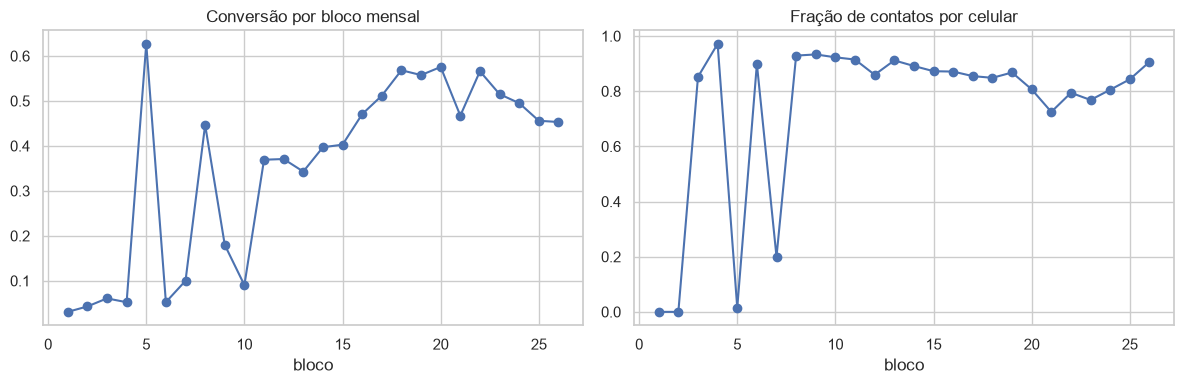

In [11]:
df0["bloco"] = (df0["month"] != df0["month"].shift()).cumsum()
por_bloco = df0.groupby("bloco").agg(mes=("month", "first"), n=("conv", "size"),
                                     conversao=("conv", "mean"),
                                     share_celular=("contact", lambda s: (s == "cellular").mean()))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
por_bloco["conversao"].plot(ax=ax[0], marker="o", title="Conversão por bloco mensal")
por_bloco["share_celular"].plot(ax=ax[1], marker="o", title="Fração de contatos por celular")
plt.tight_layout()
por_bloco

**Confusão temporal:** a base não tem coluna de ano, mas cada bloco corresponde a uma sequência contígua de meses (a campanha é conhecida por ter ocorrido entre maio/2008 e novembro/2010). Nos dois primeiros blocos (mai–jun) o contato foi **exclusivamente por telefone** (`share_celular == 0`) e a conversão ficou em torno de **3–4%**; já nos últimos blocos (2010) a conversão sobe para a faixa de **45–57%**, período em que o celular já domina os contatos. Comparar canais sem controlar o tempo é enganoso — a diferença observada acima é parcialmente um efeito de período, não só de canal. Isso motiva avaliar a política por blocos temporais com estimação de propensão, como faremos no notebook `02`.

**Vazamento de informação (leakage):** duas colunas não podem ser usadas para decidir o canal de contato antes da ligação:

- `duration`: a duração da chamada só é conhecida **depois** que ela acontece — usá-la fere a premissa do problema (exigência explícita do enunciado do desafio) e "prevê" o alvo por construção.
- `campaign`: conta o número de contatos **incluindo o contato atual**, ou seja, também carrega informação posterior à decisão.


In [12]:
raw.assign(conv=raw["y"].eq("yes")).groupby(pd.qcut(raw["duration"], 5))["conv"].mean()

duration
(-0.001, 89.0]     0.005246
(89.0, 146.0]      0.032436
(146.0, 222.0]     0.072758
(222.0, 368.0]     0.124556
(368.0, 4918.0]    0.329968
Name: conv, dtype: float64

A conversão sobe de forma monotônica e acentuada com `duration` (de ≈0,5% no quintil mais curto a ≈33,0% no mais longo), confirmando que essa coluna "prevê" o alvo por ser posterior a ele — reforço de que precisa ser removida antes do treino.

In [13]:
raw.duplicated().sum()

np.int64(12)

## Tratamento dos dados

A função `clean` (pacote `datathon.data`) aplica o tratamento definido acima: remove as **12** linhas duplicadas, descarta as colunas de leakage, cria o alvo binário `reward`, o bloco temporal `block`, o braço `arm` (código do canal) e o `segment` (idade × sucesso anterior). `evaluation_set` mantém apenas os blocos em que os dois canais aparecem e calcula a propensão logada de cada braço por bloco.

In [14]:
df = clean(raw)
ev = evaluation_set(df)
print(LEAKAGE_COLUMNS, df.shape, ev.shape)
df[["age", "poutcome", "contact", "segment", "arm", "block", "reward"]].head()

('duration', 'campaign') (41176, 23) (29040, 24)


,age,poutcome,contact,segment,arm,block,reward
0,56,nonexistent,telephone,adulto_sem_sucesso,1,1,0
1,57,nonexistent,telephone,adulto_sem_sucesso,1,1,0
2,37,nonexistent,telephone,adulto_sem_sucesso,1,1,0
3,40,nonexistent,telephone,adulto_sem_sucesso,1,1,0
4,56,nonexistent,telephone,adulto_sem_sucesso,1,1,0


In [15]:
df["segment"].value_counts()

segment
adulto_sem_sucesso    31801
jovem_sem_sucesso      7014
senior_sem_sucesso      988
adulto_com_sucesso      802
jovem_com_sucesso       367
senior_com_sucesso      204
Name: count, dtype: int64

## Resumo

- A base tem 41.188 linhas e uma conversão global de **≈11,3%** (bastante desbalanceada).
- O canal **celular** converte mais que **telefone** na maioria dos segmentos de idade × sucesso anterior; a única exceção (≥60 anos com sucesso anterior) tem amostra pequena demais (telefone `n=13`) para ser conclusiva.
- Há um **forte efeito temporal**: no início da campanha (mai–jun) o contato foi só por telefone e a conversão era baixa (~3–4%); no fim (2010) a conversão chega a 45–57% e o celular já predomina. Comparações de canal precisam controlar o tempo (ver notebook `02`).
- `duration` e `campaign` foram removidas por **leakage**: ambas carregam informação só disponível depois (ou durante) o contato atual, o que violaria a decisão que o modelo precisa tomar antes de ligar.
- Foram removidas **12 linhas duplicadas** (`keep="first"`).
- Os **segmentos** do bandit contextual foram definidos por **idade (≤30 / 31–59 / ≥60) × sucesso em campanha anterior**, por serem os dois fatores com maior poder discriminante e disponíveis antes do contato. **Limitação:** os cortes de idade e a própria escolha das variáveis de segmentação foram definidos observando a base inteira (incluindo o que viria a ser o conjunto de teste), então a segmentação em si não é livre de *data snooping* — decisão aceita aqui por simplicidade, mas que vale registrar como limitação do estudo.